<a href="https://colab.research.google.com/github/djtheconqueror/home_ai/blob/main/Readiness_AI_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Readiness AI v1

Readiness AI is an early-stage machine learning project focused on predicting human performance readiness using synthetic health, fatigue, and workload signals.

The model estimates whether an individual is ready, at caution risk, or should prioritize recovery based on variables such as sleep, stress, hydration, soreness, training load, resting heart rate, and cognitive fatigue.

In [2]:
!pip install scikit-learn pandas numpy matplotlib joblib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

In [3]:
rng = np.random.default_rng(42)
n = 800

data = pd.DataFrame({
    "sleep_hours": rng.uniform(3, 10, n),
    "stress_score": rng.uniform(0, 1, n),
    "hydration_score": rng.uniform(0, 1, n),
    "soreness_score": rng.uniform(0, 1, n),
    "training_load": rng.uniform(0, 1, n),
    "resting_hr": rng.uniform(45, 90, n),
    "cognitive_fatigue": rng.uniform(0, 1, n),
})

# Normalize resting HR into a risk-style feature
hr_risk = (data["resting_hr"] - 45) / (90 - 45)

# Higher score = worse readiness risk
fatigue_risk_score = (
    0.25 * (1 - data["sleep_hours"] / 10) +
    0.20 * data["stress_score"] +
    0.15 * (1 - data["hydration_score"]) +
    0.15 * data["soreness_score"] +
    0.10 * data["training_load"] +
    0.10 * hr_risk +
    0.05 * data["cognitive_fatigue"]
)

data["readiness_label"] = pd.cut(
    fatigue_risk_score,
    bins=[-0.01, 0.35, 0.60, 1.01],
    labels=["READY", "CAUTION", "RECOVER"]
)

data.head()

,sleep_hours,stress_score,hydration_score,soreness_score,training_load,resting_hr,cognitive_fatigue,readiness_label
0,8.417692,0.738580,0.913285,0.596445,0.761508,77.224499,0.436852,CAUTION
1,6.072149,0.317153,0.140055,0.792271,0.922739,61.070202,0.208727,CAUTION
2,9.010185,0.890019,0.677709,0.753073,0.916680,83.334054,0.046065,CAUTION
3,7.881576,0.593831,0.814474,0.892541,0.649393,55.843972,0.462630,CAUTION
4,3.659241,0.126026,0.235256,0.805773,0.928239,69.227707,0.814775,RECOVER


In [4]:
feature_cols = [
    "sleep_hours",
    "stress_score",
    "hydration_score",
    "soreness_score",
    "training_load",
    "resting_hr",
    "cognitive_fatigue",
]

X = data[feature_cols]
y = data["readiness_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     CAUTION       0.89      0.98      0.94       118
       READY       0.91      0.81      0.86        26
     RECOVER       1.00      0.44      0.61        16

    accuracy                           0.90       160
   macro avg       0.94      0.74      0.80       160
weighted avg       0.91      0.90      0.89       160



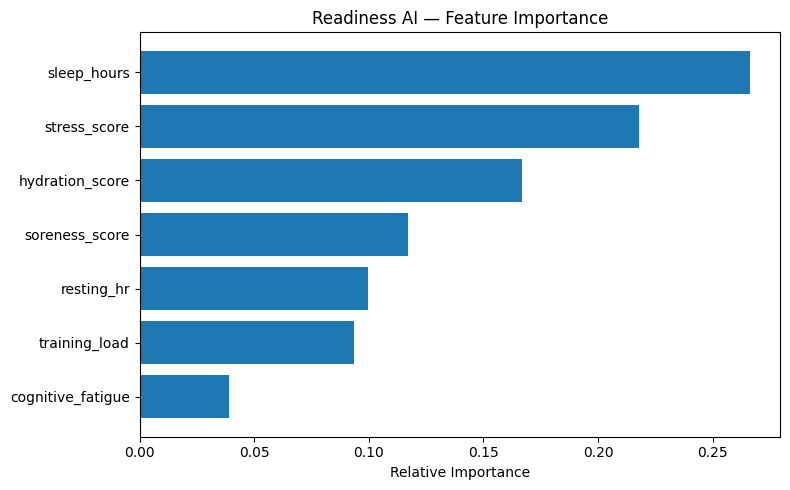

In [5]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.title("Readiness AI — Feature Importance")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [6]:
def readiness_score(sample_dict):
    x = pd.DataFrame([sample_dict])[feature_cols]

    prediction = model.predict(x)[0]
    probabilities = model.predict_proba(x)[0]
    class_order = model.classes_

    prob_map = {
        cls: float(prob)
        for cls, prob in zip(class_order, probabilities)
    }

    risk_probability = prob_map.get("RECOVER", 0) + 0.5 * prob_map.get("CAUTION", 0)

    readiness_percent = round((1 - risk_probability) * 100, 1)

    explanation_bullets = []

    if sample_dict["sleep_hours"] < 6:
        explanation_bullets.append("Low sleep is reducing readiness.")
    if sample_dict["stress_score"] > 0.65:
        explanation_bullets.append("High stress is increasing fatigue risk.")
    if sample_dict["hydration_score"] < 0.45:
        explanation_bullets.append("Low hydration may impair performance.")
    if sample_dict["soreness_score"] > 0.65:
        explanation_bullets.append("High soreness suggests incomplete recovery.")
    if sample_dict["training_load"] > 0.75:
        explanation_bullets.append("Recent training load is elevated.")
    if sample_dict["resting_hr"] > 75:
        explanation_bullets.append("Elevated resting heart rate may indicate strain.")
    if sample_dict["cognitive_fatigue"] > 0.65:
        explanation_bullets.append("Cognitive fatigue is elevated.")

    if not explanation_bullets:
        explanation_bullets.append("Most readiness indicators are within acceptable ranges.")

    explanation = {
        "prediction": prediction,
        "readiness_percent": readiness_percent,
        "probabilities": prob_map,
        "bullets": explanation_bullets,
        "summary": f"Readiness AI estimates this profile as {prediction} with a readiness score of {readiness_percent}%."
    }

    return prediction, readiness_percent, explanation

In [7]:
sample = {
    "sleep_hours": 5.5,
    "stress_score": 0.72,
    "hydration_score": 0.38,
    "soreness_score": 0.70,
    "training_load": 0.82,
    "resting_hr": 78,
    "cognitive_fatigue": 0.67,
}

prediction, readiness_percent, explanation = readiness_score(sample)

print("=== Readiness AI Report ===")
print(explanation["summary"])
print()
print("Prediction:", prediction)
print("Readiness Score:", readiness_percent)
print()
print("Key Factors:")
for bullet in explanation["bullets"]:
    print("•", bullet)

=== Readiness AI Report ===
Readiness AI estimates this profile as RECOVER with a readiness score of 14.8%.

Prediction: RECOVER
Readiness Score: 14.8

Key Factors:
• Low sleep is reducing readiness.
• High stress is increasing fatigue risk.
• Low hydration may impair performance.
• High soreness suggests incomplete recovery.
• Recent training load is elevated.
• Elevated resting heart rate may indicate strain.
• Cognitive fatigue is elevated.


In [8]:
scenarios = {
    "Fully Recovered": {
        "sleep_hours": 8.2,
        "stress_score": 0.20,
        "hydration_score": 0.88,
        "soreness_score": 0.18,
        "training_load": 0.35,
        "resting_hr": 55,
        "cognitive_fatigue": 0.20,
    },
    "Mentally Drained": {
        "sleep_hours": 6.5,
        "stress_score": 0.76,
        "hydration_score": 0.62,
        "soreness_score": 0.35,
        "training_load": 0.45,
        "resting_hr": 66,
        "cognitive_fatigue": 0.88,
    },
    "Overtrained": {
        "sleep_hours": 5.8,
        "stress_score": 0.55,
        "hydration_score": 0.50,
        "soreness_score": 0.83,
        "training_load": 0.91,
        "resting_hr": 76,
        "cognitive_fatigue": 0.50,
    },
    "High Risk Recovery Needed": {
        "sleep_hours": 4.7,
        "stress_score": 0.84,
        "hydration_score": 0.32,
        "soreness_score": 0.78,
        "training_load": 0.86,
        "resting_hr": 82,
        "cognitive_fatigue": 0.81,
    },
}

In [9]:
def score_readiness_scenarios(scenarios):
    rows = []

    for name, sample in scenarios.items():
        prediction, readiness_percent, explanation = readiness_score(sample)

        rows.append({
            "scenario": name,
            "prediction": prediction,
            "readiness_score": readiness_percent,
            "summary": explanation["summary"],
        })

    return pd.DataFrame(rows).sort_values("readiness_score", ascending=False)

scenario_results = score_readiness_scenarios(scenarios)
scenario_results

,scenario,prediction,readiness_score,summary
0,Fully Recovered,READY,97.4,Readiness AI estimates this profile as READY w...
1,Mentally Drained,CAUTION,53.4,Readiness AI estimates this profile as CAUTION...
2,Overtrained,CAUTION,41.0,Readiness AI estimates this profile as CAUTION...
3,High Risk Recovery Needed,RECOVER,6.9,Readiness AI estimates this profile as RECOVER...


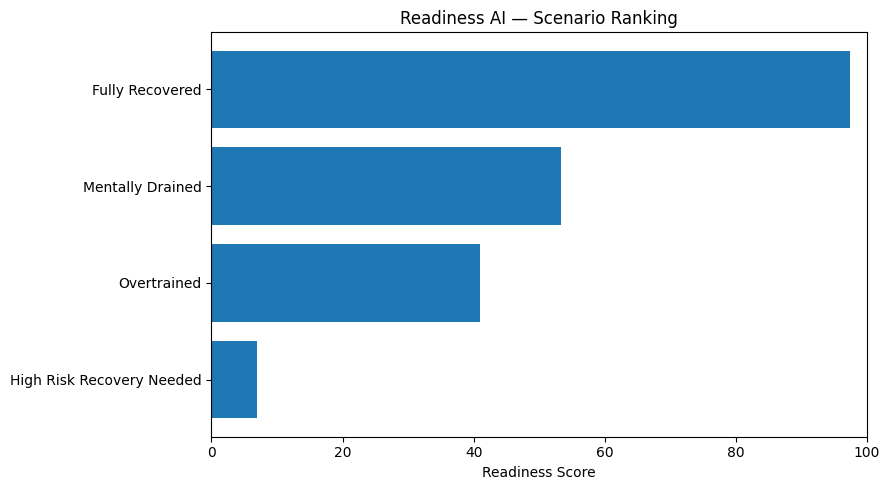

In [10]:
plt.figure(figsize=(9, 5))
plt.barh(
    scenario_results["scenario"],
    scenario_results["readiness_score"]
)

plt.xlabel("Readiness Score")
plt.title("Readiness AI — Scenario Ranking")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
def executive_readiness_report(sample, name="Profile"):
    prediction, readiness_percent, explanation = readiness_score(sample)

    print("=" * 60)
    print(f"READINESS AI EXECUTIVE REPORT — {name}")
    print("=" * 60)
    print()
    print(f"Decision: {prediction}")
    print(f"Readiness Score: {readiness_percent}%")
    print()
    print("Summary:")
    print(explanation["summary"])
    print()
    print("Key Factors:")
    for bullet in explanation["bullets"]:
        print(f" - {bullet}")

    df_sample = pd.DataFrame([sample])[feature_cols]

    plt.figure(figsize=(8, 4))
    df_sample.T[0].plot(kind="bar")
    plt.title(f"Feature Profile — {name}")
    plt.ylabel("Raw Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

READINESS AI EXECUTIVE REPORT — High Risk Recovery Needed

Decision: RECOVER
Readiness Score: 6.9%

Summary:
Readiness AI estimates this profile as RECOVER with a readiness score of 6.9%.

Key Factors:
 - Low sleep is reducing readiness.
 - High stress is increasing fatigue risk.
 - Low hydration may impair performance.
 - High soreness suggests incomplete recovery.
 - Recent training load is elevated.
 - Elevated resting heart rate may indicate strain.
 - Cognitive fatigue is elevated.


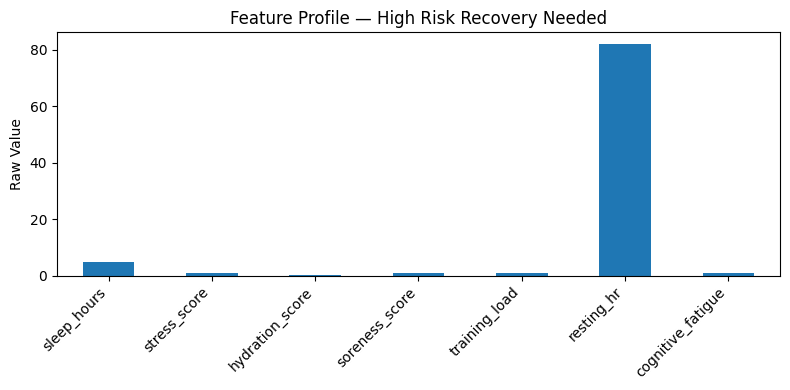

In [12]:
executive_readiness_report(
    scenarios["High Risk Recovery Needed"],
    name="High Risk Recovery Needed"
)

In [13]:
artifact = {
    "model": model,
    "feature_cols": feature_cols,
    "classes": list(model.classes_),
}

joblib.dump(artifact, "readiness_ai_rf.pkl")

print("Saved model artifact: readiness_ai_rf.pkl")

Saved model artifact: readiness_ai_rf.pkl


In [14]:
print("READINESS AI v1 — PROJECT SUMMARY")
print("=" * 55)
print()
print("Purpose:")
print("Readiness AI estimates human performance readiness using synthetic health, fatigue, and workload signals.")
print()
print("Model:")
print("- RandomForestClassifier")
print("- Multi-class prediction: READY / CAUTION / RECOVER")
print("- Inputs: sleep, stress, hydration, soreness, training load, resting heart rate, cognitive fatigue")
print()
print("Current Capabilities:")
print("- Synthetic readiness dataset generation")
print("- Fatigue/readiness classification")
print("- Scenario-based testing")
print("- Executive report generation")
print("- Feature importance visualization")
print("- Model artifact export")
print()
print("Portfolio Alignment:")
print("This project supports my broader interest in AI-driven human performance, defense health, and operational readiness analytics.")
print()
print("Next Steps:")
print("- Add real or public wearable-style datasets")
print("- Build a Streamlit dashboard")
print("- Add time-series readiness tracking")
print("- Add individualized baseline modeling")
print("- Compare multiple ML models")

READINESS AI v1 — PROJECT SUMMARY

Purpose:
Readiness AI estimates human performance readiness using synthetic health, fatigue, and workload signals.

Model:
- RandomForestClassifier
- Multi-class prediction: READY / CAUTION / RECOVER
- Inputs: sleep, stress, hydration, soreness, training load, resting heart rate, cognitive fatigue

Current Capabilities:
- Synthetic readiness dataset generation
- Fatigue/readiness classification
- Scenario-based testing
- Executive report generation
- Feature importance visualization
- Model artifact export

Portfolio Alignment:
This project supports my broader interest in AI-driven human performance, defense health, and operational readiness analytics.

Next Steps:
- Add real or public wearable-style datasets
- Build a Streamlit dashboard
- Add time-series readiness tracking
- Add individualized baseline modeling
- Compare multiple ML models


In [15]:
scenario_results.to_csv("readiness_ai_scenario_report.csv", index=False)
print("Saved report: readiness_ai_scenario_report.csv")

Saved report: readiness_ai_scenario_report.csv


In [16]:
from google.colab import files

files.download("readiness_ai_rf.pkl")
files.download("readiness_ai_scenario_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>